In [93]:
## Libraries

import yfinance as yf
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from scipy import stats
from scipy import stats as scipy_stats



In [94]:
## Data (yfinance)

# --- Config ---
TICKER = "SPY"              # SPY US Equity — consistent with your Bloomberg plan later
START_DATE = "2005-01-01"   # ~20 years: gives enough range for large-lag structure functions
END_DATE = None             # None = up to today

def download_data(ticker=TICKER, start=START_DATE, end=END_DATE):
    df = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
    df = df[['Close']].rename(columns={'Close': 'close'})
    df.index.name = 'date'
    return df

data = download_data()

# Flatten MultiIndex columns if present (newer yfinance versions do this even for single tickers)
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

print(data.columns)      # should just show: Index(['close'], dtype='object')
print(type(data['close']))  # should be <class 'pandas.core.series.Series'>

# --- Sanity checks ---
print(f"Shape: {data.shape}")
print(f"Date range: {data.index.min()} to {data.index.max()}")
print(f"Missing values: {data['close'].isna().sum()}")
print(f"Duplicate dates: {data.index.duplicated().sum()}")
print("\nHead:")
print(data.head())
print("\nTail:")
print(data.tail())




Index(['close'], dtype='object', name='Price')
<class 'pandas.core.series.Series'>
Shape: (5410, 1)
Date range: 2005-01-03 00:00:00 to 2026-07-07 00:00:00
Missing values: 0
Duplicate dates: 0

Head:
Price           close
date                 
2005-01-03  81.174591
2005-01-04  80.182709
2005-01-05  79.629395
2005-01-06  80.034218
2005-01-07  79.919533

Tail:
Price            close
date                  
2026-06-30  746.770020
2026-07-01  745.760010
2026-07-02  744.780029
2026-07-06  751.280029
2026-07-07  748.820007


Log return stats: 
count    5409.000000
mean        0.000411
std         0.011947
min        -0.115887
25%        -0.003943
50%         0.000717
75%         0.005796
max         0.135578
Name: log_return, dtype: float64
Skewness: -0.3045
Excess Kurtosis: 14.6871


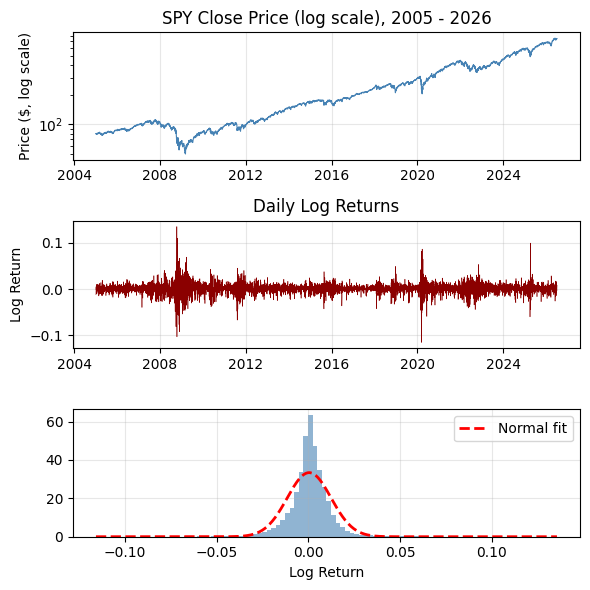

In [95]:
data['log_price'] = np.log(data['close'])
data['log_return'] = data['log_price'].diff()
data = data.dropna(subset=['log_return'])


print(f"Log return stats: ")
print(data['log_return'].describe())
print(f"Skewness: {stats.skew(data['log_return']):.4f}")
print(f"Excess Kurtosis: {stats.kurtosis(data['log_return']):.4f}")


fig, axes = plt.subplots(3, 1, figsize= (6, 6))

axes[0].plot(data.index, data['close'], linewidth = 0.8, color = 'steelblue')
axes[0].set_yscale('log')
axes[0].set_title(f'SPY Close Price (log scale), {data.index.min().year} - {data.index.max().year}')
axes[0].set_ylabel('Price ($, log scale)')
axes[0].grid(alpha = 0.3)

axes[1].plot(data.index, data['log_return'], linewidth = 0.4, color='darkred')
axes[1].set_title('Daily Log Returns')
axes[1].set_ylabel('Log Return')
axes[1].grid(alpha = 0.3)

axes[2].hist(data['log_return'], bins = 100, density = True, alpha = 0.6, color = 'steelblue')
mu, sigma = data['log_return'].mean(), data['log_return'].std()
x = np.linspace(data['log_return'].min(), data['log_return'].max(), 500)
axes[2].plot(x, stats.norm.pdf(x, mu, sigma), 'r--', linewidth = 2, label='Normal fit')
axes[2].set_xlabel('Log Return')
axes[2].legend()
axes[2].grid(alpha = 0.3)

plt.tight_layout()
plt.savefig('Module1_data_check.png')
plt.show()

In [96]:
def compute_structure_functions(log_price, lags, q_values):
    results = pd.DataFrame(index = lags, columns = q_values, dtype = float)

    for tau in lags:
        increments = log_price.diff(tau).dropna()
        abs_increments = increments.abs()

        for q in q_values:
            results.loc[tau, q] = (abs_increments ** q).mean()

    return results

# --- Config ---
LAGS = np.array([1, 2, 3, 4, 5, 6, 8, 10, 13, 16, 20, 25, 30, 40, 50, 60])
Q_VALUES = [1, 2, 3, 4]

structure_functions = compute_structure_functions(data['log_price'], LAGS, Q_VALUES)

print("Structure functions S_q(tau):")
print(structure_functions)
print(f"\nNumber of increments used at largest lag (tau={LAGS[-1]}): "
      f"{data['log_price'].diff(LAGS[-1]).dropna().shape[0]}")

Structure functions S_q(tau):
           1         2         3             4
1   0.007662  0.000143  0.000005  3.594890e-07
2   0.010866  0.000257  0.000011  7.986518e-07
3   0.013243  0.000369  0.000018  1.421349e-06
4   0.015185  0.000483  0.000029  2.721178e-06
5   0.016773  0.000589  0.000038  4.089321e-06
6   0.018264  0.000692  0.000049  5.680369e-06
8   0.020879  0.000894  0.000071  9.199795e-06
10  0.023273  0.001101  0.000098  1.442736e-05
13  0.026877  0.001438  0.000144  2.333342e-05
16  0.030060  0.001754  0.000187  3.137860e-05
20  0.033863  0.002181  0.000259  5.069917e-05
25  0.038250  0.002718  0.000343  6.906627e-05
30  0.041701  0.003240  0.000431  8.743935e-05
40  0.048343  0.004295  0.000651  1.495411e-04
50  0.055357  0.005371  0.000855  2.021927e-04
60  0.061298  0.006312  0.001030  2.470680e-04

Number of increments used at largest lag (tau=60): 5349


In [97]:

def estimate_zeta(structure_functions, q_values, lags):
    """
    For each q, regress log(S_q(tau)) on log(tau).
    Returns a DataFrame with zeta(q), R^2, and standard error of the slope.
    """
    results = []
    log_lags = np.log(lags)
    
    for q in q_values:
        log_Sq = np.log(structure_functions[q].values)
        slope, intercept, r_value, p_value, std_err = scipy_stats.linregress(log_lags, log_Sq)
        results.append({
            'q': q,
            'zeta_q': slope,
            'intercept': intercept,
            'r_squared': r_value**2,
            'std_err': std_err
        })
    
    return pd.DataFrame(results)

zeta_results = estimate_zeta(structure_functions, Q_VALUES, LAGS)
print(zeta_results)

# Hurst exponent from zeta(2)
H_from_zeta2 = zeta_results.loc[zeta_results['q'] == 2, 'zeta_q'].values[0] / 2
print(f"\nH (from zeta(2)/2): {H_from_zeta2:.4f}")

# GBM benchmark comparison (zeta(q) = q/2 under GBM/Brownian motion)
zeta_results['gbm_benchmark'] = zeta_results['q'] / 2
zeta_results['deviation_from_gbm'] = zeta_results['zeta_q'] - zeta_results['gbm_benchmark']
print("\nComparison to GBM benchmark (zeta(q) = q/2):")
print(zeta_results[['q', 'zeta_q', 'gbm_benchmark', 'deviation_from_gbm', 'r_squared']])

   q    zeta_q  intercept  r_squared   std_err
0  1  0.504976  -4.892527   0.999053  0.004155
1  2  0.936424  -8.926538   0.999294  0.006650
2  3  1.325258 -12.268860   0.998773  0.012413
3  4  1.688589 -15.085182   0.996828  0.025458

H (from zeta(2)/2): 0.4682

Comparison to GBM benchmark (zeta(q) = q/2):
   q    zeta_q  gbm_benchmark  deviation_from_gbm  r_squared
0  1  0.504976            0.5            0.004976   0.999053
1  2  0.936424            1.0           -0.063576   0.999294
2  3  1.325258            1.5           -0.174742   0.998773
3  4  1.688589            2.0           -0.311411   0.996828


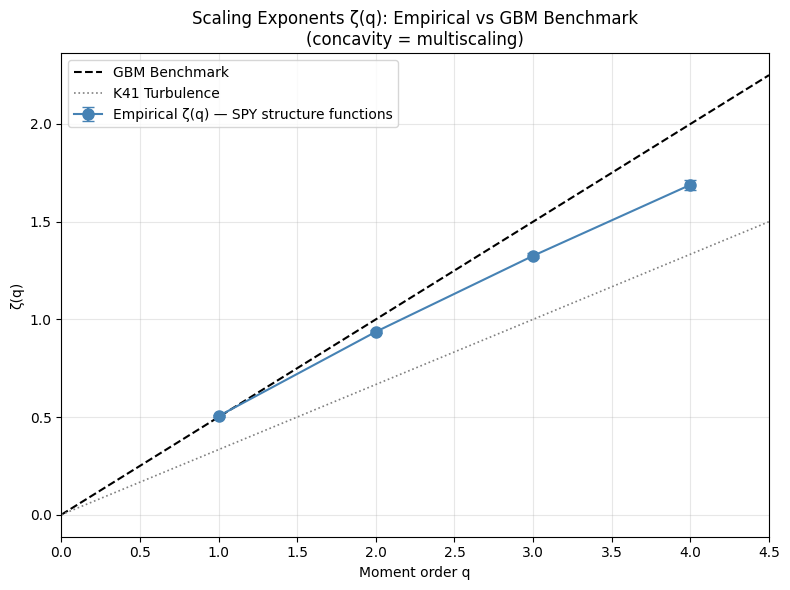

In [98]:
fig, ax = plt.subplots(figsize=(8, 6))

q_range = np.linspace(0, 4.5, 100)

ax.plot(q_range, q_range / 2, 'k--', linewidth= 1.5, label = "GBM Benchmark")
ax.plot(q_range, q_range / 3, color = 'gray', linestyle = ":", linewidth = 1.2, label = 'K41 Turbulence')

ax.errorbar(
    zeta_results['q'], zeta_results['zeta_q'],
    yerr = zeta_results['std_err'],
    fmt = "o-", color = 'steelblue', markersize = 8, capsize = 4, 
    linewidth = 1.5, label = 'Empirical ζ(q) — SPY structure functions'
)

ax.set_xlabel('Moment order q')
ax.set_ylabel('ζ(q)')
ax.set_title('Scaling Exponents ζ(q): Empirical vs GBM Benchmark\n(concavity = multiscaling)')
ax.legend()
ax.grid(alpha = 0.3)
ax.set_xlim(0, 4.5)

plt.tight_layout()
plt.savefig('Module1_zeta_q_plot.png')
plt.show()


In [99]:
def rs_analysis(returns, window_sizes):
    returns = returns.values
    N = len(returns)
    results = []

    for n in window_sizes:
        n = int(n)
        num_windows = N // n
        if num_windows < 1:
            continue

        rs_values = []
        for i in range(num_windows):
            window = returns[i*n : (i+1)*n]
            mean_ret = window.mean()
            deviations = window - mean_ret
            cumulative_dev = np.cumsum(deviations)

            R = cumulative_dev.max() - cumulative_dev.min()
            S = window.std(ddof=1)

            if S>0:
                rs_values.append(R /S)
        if len(rs_values) > 0:
            results.append({'n': n, 'mean_rs': np.mean(rs_values), 'num_windows': len(rs_values)})
    return pd.DataFrame(results)

WINDOW_SIZES = np.unique(np.logspace(np.log10(10), np.log10(len(data)//4), 20).astype(int))

rs_results = rs_analysis(data['log_return'], WINDOW_SIZES)
print(rs_results)

# --- Regression: log(R/S) vs log(n) ---
log_n = np.log(rs_results['n'])
log_rs = np.log(rs_results['mean_rs'])
slope, intercept, r_value, p_value, std_err = scipy_stats.linregress(log_n, log_rs)

print(f"\nH (R/S analysis): {slope:.4f}")
print(f"R-squared: {r_value**2:.4f}")
print(f"Std error: {std_err:.4f}")

       n    mean_rs  num_windows
0     10   2.841469          540
1     12   3.191624          450
2     16   3.776844          338
3     21   4.422571          257
4     28   5.228518          193
5     36   6.035174          150
6     47   7.099148          115
7     60   7.926185           90
8     78   9.296045           69
9    102  10.583428           53
10   132  11.759002           40
11   171  13.656857           31
12   221  15.176757           24
13   287  17.277231           18
14   371  19.569533           14
15   481  22.351399           11
16   623  26.993402            8
17   806  32.596248            6
18  1044  36.183037            5
19  1352  42.204962            4

H (R/S analysis): 0.5366
R-squared: 0.9986
Std error: 0.0048


In [100]:
def dfa_analysis(returns, window_sizes, order=1):
    returns = returns.values
    N = len(returns)
    
    # Step 1: build the profile (integrated, mean-centered series)
    profile = np.cumsum(returns - returns.mean())
    
    results = []
    
    for n in window_sizes:
        n = int(n)
        num_windows = N // n
        if num_windows < 1:
            continue
        
        fluctuations = []
        x = np.arange(n)
        
        for i in range(num_windows):
            segment = profile[i*n : (i+1)*n]
            
            # Fit and remove local linear trend
            coeffs = np.polyfit(x, segment, order)
            trend = np.polyval(coeffs, x)
            detrended = segment - trend
            
            # RMS fluctuation for this window
            fluctuations.append(np.sqrt(np.mean(detrended**2)))
        
        if len(fluctuations) > 0:
            results.append({
                'n': n,
                'F_n': np.mean(fluctuations),
                'num_windows': len(fluctuations)
            })
    
    return pd.DataFrame(results)

# --- Config: same window sizes as R/S for direct comparability ---
dfa_results = dfa_analysis(data['log_return'], WINDOW_SIZES, order=1)
print(dfa_results)

# --- Regression: log(F(n)) vs log(n) ---
log_n_dfa = np.log(dfa_results['n'])
log_Fn = np.log(dfa_results['F_n'])
slope_dfa, intercept_dfa, r_value_dfa, p_value_dfa, std_err_dfa = scipy_stats.linregress(log_n_dfa, log_Fn)

print(f"\nH (DFA): {slope_dfa:.4f}")
print(f"R-squared: {r_value_dfa**2:.4f}")
print(f"Std error: {std_err_dfa:.4f}")

       n       F_n  num_windows
0     10  0.007373          540
1     12  0.008264          450
2     16  0.009477          338
3     21  0.010526          257
4     28  0.012377          193
5     36  0.013944          150
6     47  0.015857          115
7     60  0.018421           90
8     78  0.020458           69
9    102  0.023697           53
10   132  0.025015           40
11   171  0.028857           31
12   221  0.033419           24
13   287  0.039059           18
14   371  0.042191           14
15   481  0.045213           11
16   623  0.055026            8
17   806  0.068794            6
18  1044  0.083551            5
19  1352  0.087628            4

H (DFA): 0.4975
R-squared: 0.9962
Std error: 0.0073


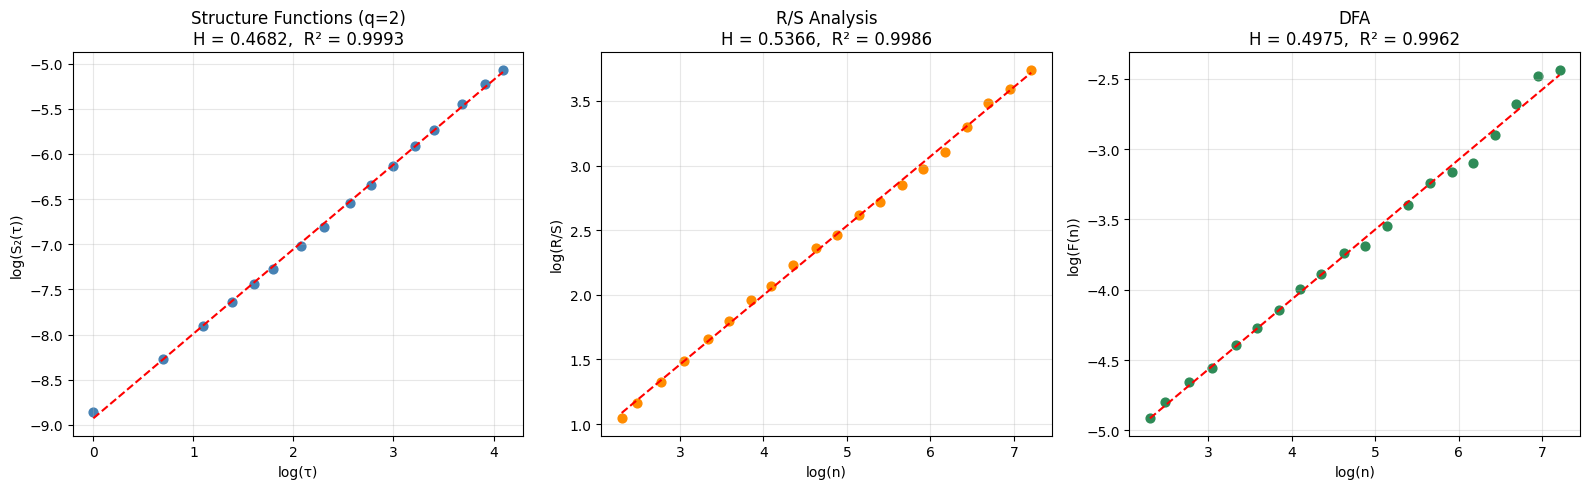

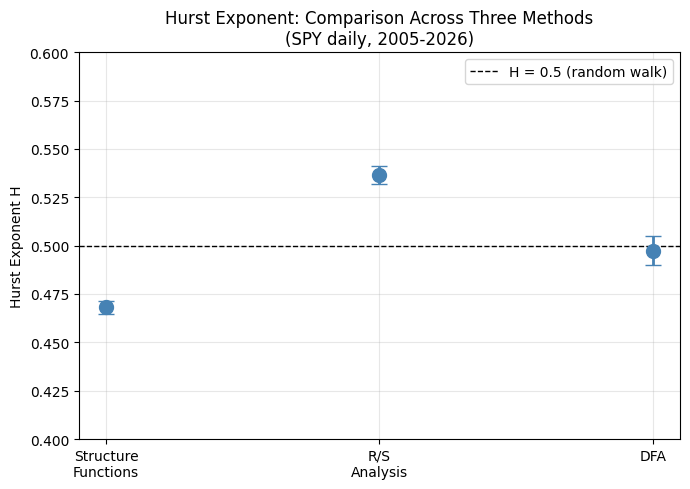

                 Method         H   Std_Err  R_squared
0  Structure\nFunctions  0.468212  0.003325   0.999294
1         R/S\nAnalysis  0.536566  0.004808   0.998557
2                   DFA  0.497456  0.007286   0.996153


In [101]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Panel 1: Structure functions (q=2) ---
log_lags_sf = np.log(LAGS)
log_S2 = np.log(structure_functions[2].values)
row_sf = zeta_results[zeta_results['q'] == 2].iloc[0]
fit_sf = row_sf['intercept'] + row_sf['zeta_q'] * log_lags_sf

axes[0].scatter(log_lags_sf, log_S2, color='steelblue', s=40)
axes[0].plot(log_lags_sf, fit_sf, 'r--', linewidth=1.5)
axes[0].set_title(f'Structure Functions (q=2)\nH = {row_sf["zeta_q"]/2:.4f},  R² = {row_sf["r_squared"]:.4f}')
axes[0].set_xlabel('log(τ)')
axes[0].set_ylabel('log(S₂(τ))')
axes[0].grid(alpha=0.3)

# --- Panel 2: R/S analysis ---
axes[1].scatter(log_n, log_rs, color='darkorange', s=40)
fit_rs = intercept + slope * log_n
axes[1].plot(log_n, fit_rs, 'r--', linewidth=1.5)
axes[1].set_title(f'R/S Analysis\nH = {slope:.4f},  R² = {r_value**2:.4f}')
axes[1].set_xlabel('log(n)')
axes[1].set_ylabel('log(R/S)')
axes[1].grid(alpha=0.3)

# --- Panel 3: DFA ---
axes[2].scatter(log_n_dfa, log_Fn, color='seagreen', s=40)
fit_dfa = intercept_dfa + slope_dfa * log_n_dfa
axes[2].plot(log_n_dfa, fit_dfa, 'r--', linewidth=1.5)
axes[2].set_title(f'DFA\nH = {slope_dfa:.4f},  R² = {r_value_dfa**2:.4f}')
axes[2].set_xlabel('log(n)')
axes[2].set_ylabel('log(F(n))')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('module2_loglog_diagnostics.png', dpi=150)
plt.show()

# --- Summary comparison plot: H estimates with error bars ---
fig2, ax2 = plt.subplots(figsize=(7, 5))

methods = ['Structure\nFunctions', 'R/S\nAnalysis', 'DFA']
H_values = [row_sf['zeta_q']/2, slope, slope_dfa]
# Note: std_err for structure functions is on zeta(2), so divide by 2 for H's std err
H_errors = [row_sf['std_err']/2, std_err, std_err_dfa]

ax2.errorbar(methods, H_values, yerr=H_errors, fmt='o', markersize=10,
             capsize=6, color='steelblue', linewidth=2)
ax2.axhline(0.5, color='black', linestyle='--', linewidth=1, label='H = 0.5 (random walk)')
ax2.set_ylabel('Hurst Exponent H')
ax2.set_title('Hurst Exponent: Comparison Across Three Methods\n(SPY daily, 2005-2026)')
ax2.set_ylim(0.4, 0.6)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('module2_H_comparison.png', dpi=150)
plt.show()

# --- Summary table ---
summary_table = pd.DataFrame({
    'Method': methods,
    'H': H_values,
    'Std_Err': H_errors,
    'R_squared': [row_sf['r_squared'], r_value**2, r_value_dfa**2]
})
print(summary_table)

In [102]:
# Refit DFA excluding the noisiest large-n points (num_windows < 6)
dfa_trimmed = dfa_results[dfa_results['num_windows'] >= 6]

log_n_trim = np.log(dfa_trimmed['n'])
log_Fn_trim = np.log(dfa_trimmed['F_n'])
slope_trim, intercept_trim, r_trim, p_trim, se_trim = scipy_stats.linregress(log_n_trim, log_Fn_trim)

print(f"DFA (trimmed, num_windows>=6): H = {slope_trim:.4f}, R² = {r_trim**2:.4f}, dropped {len(dfa_results)-len(dfa_trimmed)} points")

DFA (trimmed, num_windows>=6): H = 0.4853, R² = 0.9973, dropped 2 points


In [103]:
def davies_harte_fgn(N, H, seed=None):
    """
    Simulates fractional Gaussian noise (fGn) of length N with Hurst exponent H,
    using the Davies-Harte circulant embedding method.
    
    Fix vs. earlier version: the original implementation generated fully independent
    complex Gaussian noise across all frequency bins before inverse-FFT-ing and taking
    the real part. This discards the Hermitian symmetry required for a correctly-scaled
    real output, and was silently halving the variance of the simulated noise (verified:
    variance came out ~0.50 instead of the required 1.0). This version enforces that
    symmetry explicitly, and reproduces unit variance and correct H recovery.
    """
    rng = np.random.default_rng(seed)

    def autocov(k, H):
        return 0.5 * (abs(k+1)**(2*H) - 2*abs(k)**(2*H) + abs(k-1)**(2*H))

    k = np.arange(0, N)
    gamma = autocov(k, H)
    row = np.concatenate([gamma, [autocov(N, H)], gamma[1:][::-1]])  # circulant row, length 2N
    M = 2 * N

    eigenvalues = np.fft.fft(row).real
    if np.min(eigenvalues) < -1e-8:
        raise ValueError(f"Negative eigenvalue: {np.min(eigenvalues):.2e} for H={H}, N={N}")
    eigenvalues = np.maximum(eigenvalues, 0)
    sqrt_eig = np.sqrt(eigenvalues)

    gn1 = rng.normal(size=M)
    gn2 = rng.normal(size=M)

    w = np.zeros(M, dtype=complex)
    w[0] = sqrt_eig[0] * gn1[0]
    w[N] = sqrt_eig[N] * gn2[0]
    idx = np.arange(1, N)
    w[idx] = (sqrt_eig[idx] / np.sqrt(2)) * (gn1[idx] + 1j * gn2[idx])
    w[M - idx] = np.conj(w[idx])   # enforce Hermitian symmetry -> guarantees correct real output

    f = np.fft.fft(w)
    fgn = f[:N].real / np.sqrt(2 * N)
    return fgn

def simulate_fbm(N, H, seed=None):
    """Simulates fBm path of length N by cumulative-summing fGn."""
    fgn = davies_harte_fgn(N, H, seed=seed)
    return np.cumsum(fgn)

In [104]:
def validate_fbm_hurst(H_true, N=10000, n_lags=15, seed=42):
    """
    Generates an fBm path for a given H, then re-estimates H from it
    using variance scaling (same logic as structure functions, q=2).
    """
    fbm_path = simulate_fbm(N, H_true, seed=seed)
    
    lags = np.unique(np.logspace(0, np.log10(N//10), n_lags).astype(int))
    variances = []
    
    for tau in lags:
        increments = fbm_path[tau:] - fbm_path[:-tau]
        variances.append(np.var(increments))
    
    log_lags = np.log(lags)
    log_var = np.log(variances)
    slope, intercept, r_value, _, _ = scipy_stats.linregress(log_lags, log_var)
    H_recovered = slope / 2
    
    print(f"H input:     {H_true:.4f}")
    print(f"H recovered: {H_recovered:.4f}")
    print(f"R-squared:   {r_value**2:.4f}")
    
    return H_recovered

# --- Test across a few H values, including your actual estimate ---
for H_test in [0.468, 0.5, 0.534]:
    print(f"\n--- Testing H = {H_test} ---")
    validate_fbm_hurst(H_test)


--- Testing H = 0.468 ---
H input:     0.4680
H recovered: 0.4339
R-squared:   0.9968

--- Testing H = 0.5 ---
H input:     0.5000
H recovered: 0.4633
R-squared:   0.9970

--- Testing H = 0.534 ---
H input:     0.5340
H recovered: 0.4943
R-squared:   0.9971


In [105]:
# --- Calibration inputs from actual SPY data ---
mu_daily = data['log_return'].mean()
sigma_daily = data['log_return'].std()

print(f"Calibrated daily drift (mu): {mu_daily:.6f}")
print(f"Calibrated daily volatility (sigma): {sigma_daily:.6f}")

# --- Simulation config ---
N_DAYS = 20        # max horizon needed (covers 1, 10, 20-day CVaR)
N_PATHS = 50000    # large enough for stable 99% tail estimates
H_ESTIMATES = {
    'structure_functions': 0.468,   # primary
    'dfa': 0.486,                   # trimmed
    'rs': 0.534
}

def simulate_gbm_paths(mu, sigma, n_days, n_paths, seed=42):
    """Standard GBM: iid Gaussian daily log returns."""
    np.random.seed(seed)
    daily_returns = np.random.normal(mu, sigma, size=(n_paths, n_days))
    log_price_paths = np.cumsum(daily_returns, axis=1)  # log price relative to log(S0)=0
    return log_price_paths  # shape: (n_paths, n_days)

def simulate_fbm_paths(H, mu, sigma, n_days, n_paths, seed=42):
    """Fractional GBM: fBm-driven log price paths, calibrated to mu, sigma."""
    log_price_paths = np.zeros((n_paths, n_days))
    for i in range(n_paths):
        fgn = davies_harte_fgn(n_days, H, seed=seed + i)
        daily_returns = mu + sigma * fgn   # fgn has unit variance by construction
        log_price_paths[i, :] = np.cumsum(daily_returns)
    return log_price_paths

# --- Run simulations ---
print("\nSimulating GBM paths...")
gbm_paths = simulate_gbm_paths(mu_daily, sigma_daily, N_DAYS, N_PATHS)

fbm_paths = {}
for name, H in H_ESTIMATES.items():
    print(f"Simulating fBm paths (H={H}, {name})...")
    fbm_paths[name] = simulate_fbm_paths(H, mu_daily, sigma_daily, N_DAYS, N_PATHS)

print("\nDone. Shapes:")
print(f"GBM: {gbm_paths.shape}")
for name, paths in fbm_paths.items():
    print(f"fBm ({name}): {paths.shape}")

# --- Quick sanity check: 1-day return distribution should match calibration ---
print(f"\n--- Sanity check: simulated 1-day returns vs calibration ---")
print(f"Target: mean={mu_daily:.6f}, std={sigma_daily:.6f}")
print(f"GBM day-1:            mean={gbm_paths[:,0].mean():.6f}, std={gbm_paths[:,0].std():.6f}")
for name, paths in fbm_paths.items():
    print(f"fBm ({name}) day-1:  mean={paths[:,0].mean():.6f}, std={paths[:,0].std():.6f}")

Calibrated daily drift (mu): 0.000411
Calibrated daily volatility (sigma): 0.011947

Simulating GBM paths...
Simulating fBm paths (H=0.468, structure_functions)...
Simulating fBm paths (H=0.486, dfa)...
Simulating fBm paths (H=0.534, rs)...

Done. Shapes:
GBM: (50000, 20)
fBm (structure_functions): (50000, 20)
fBm (dfa): (50000, 20)
fBm (rs): (50000, 20)

--- Sanity check: simulated 1-day returns vs calibration ---
Target: mean=0.000411, std=0.011947
GBM day-1:            mean=0.000406, std=0.011946
fBm (structure_functions) day-1:  mean=0.000524, std=0.011929
fBm (dfa) day-1:  mean=0.000525, std=0.011930
fBm (rs) day-1:  mean=0.000530, std=0.011932


In [106]:
def compute_cvar(log_returns_horizon, confidence):
    """
    Computes CVaR (Expected Shortfall) for a given confidence level.
    
    log_returns_horizon : array of simulated cumulative log returns over the horizon
    confidence          : e.g. 0.95 or 0.99
    
    Returns CVaR as a positive number representing expected loss magnitude.
    """
    var_threshold = np.percentile(log_returns_horizon, (1 - confidence) * 100)
    tail_losses = log_returns_horizon[log_returns_horizon <= var_threshold]
    cvar = -tail_losses.mean()  # positive number = expected loss magnitude
    return cvar

HORIZONS = [1, 10, 20]
CONFIDENCE_LEVELS = [0.95, 0.99]

# --- Empirical CVaR: real overlapping tau-day returns from actual SPY history ---
def empirical_cvar(log_price, horizon, confidence):
    returns_h = log_price.diff(horizon).dropna().values
    return compute_cvar(returns_h, confidence)

# --- Build results table ---
results = []
model_paths = {'GBM': gbm_paths, **{f'fBm ({name})': paths for name, paths in fbm_paths.items()}}

for horizon in HORIZONS:
    for confidence in CONFIDENCE_LEVELS:
        row = {'horizon': horizon, 'confidence': confidence}
        
        for model_name, paths in model_paths.items():
            horizon_returns = paths[:, horizon - 1]  # cumulative log return up to day = horizon
            row[model_name] = compute_cvar(horizon_returns, confidence)
        
        row['Empirical'] = empirical_cvar(data['log_price'], horizon, confidence)
        
        results.append(row)

cvar_table = pd.DataFrame(results)
print(cvar_table.to_string(index=False))

 horizon  confidence      GBM  fBm (structure_functions)  fBm (dfa)  fBm (rs)  Empirical
       1        0.95 0.024260                   0.024082   0.024080  0.024070   0.029552
       1        0.99 0.032018                   0.031146   0.031133  0.031089   0.052304
      10        0.95 0.073997                   0.068407   0.071461  0.080220   0.085063
      10        0.99 0.095501                   0.090576   0.094560  0.105990   0.157122
      20        0.95 0.103352                   0.091474   0.097005  0.113304   0.116983
      20        0.99 0.136595                   0.121528   0.128778  0.150081   0.222425


In [107]:
# Normalized CVaR growth: CVaR(tau) / CVaR(1), isolates scaling behavior from level mismatch
normalized = cvar_table.copy()
for col in ['GBM', 'fBm (structure_functions)', 'fBm (dfa)', 'fBm (rs)', 'Empirical']:
    for conf in CONFIDENCE_LEVELS:
        base = normalized.loc[(normalized['horizon']==1) & (normalized['confidence']==conf), col].values[0]
        mask = normalized['confidence'] == conf
        normalized.loc[mask, col] = normalized.loc[mask, col] / base

print(normalized.to_string(index=False))

 horizon  confidence      GBM  fBm (structure_functions)  fBm (dfa)  fBm (rs)  Empirical
       1        0.95 1.000000                   1.000000   1.000000  1.000000   1.000000
       1        0.99 1.000000                   1.000000   1.000000  1.000000   1.000000
      10        0.95 3.050226                   2.840556   2.967649  3.332816   2.878436
      10        0.99 2.982747                   2.908111   3.037246  3.409224   3.004030
      20        0.95 4.260258                   3.798388   4.028458  4.707315   3.958539
      20        0.99 4.266196                   3.901874   4.136331  4.827468   4.252564


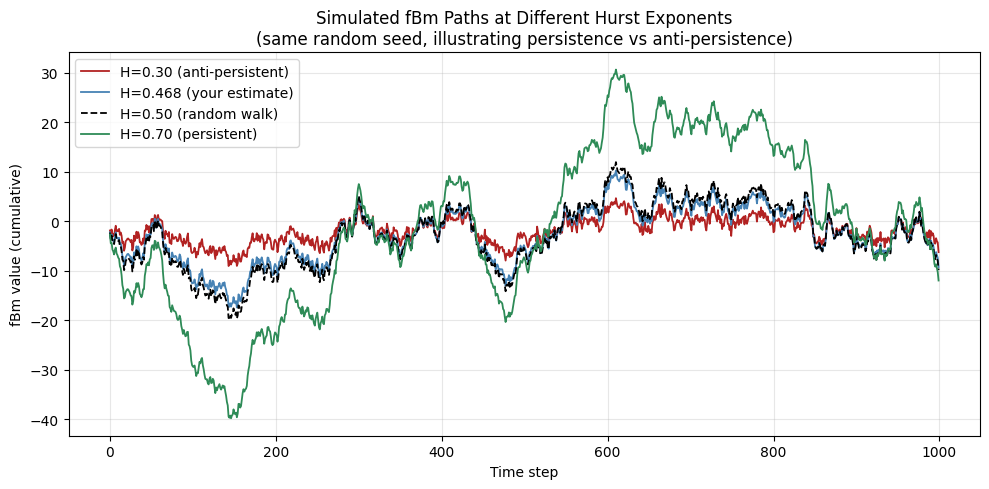

In [108]:
# --- Figure 1: Illustrative long paths, different H values (conceptual) ---
fig, ax = plt.subplots(figsize=(10, 5))

illustration_Hs = {'H=0.30 (anti-persistent)': 0.30, 
                    'H=0.468 (your estimate)': 0.468,
                    'H=0.50 (random walk)': 0.50,
                    'H=0.70 (persistent)': 0.70}

N_illustrate = 1000
colors = ['firebrick', 'steelblue', 'black', 'seagreen']

for (label, H), color in zip(illustration_Hs.items(), colors):
    path = simulate_fbm(N_illustrate, H, seed=7)  # same seed = same underlying randomness, only H differs
    style = '--' if H == 0.50 else '-'
    ax.plot(path, label=label, color=color, linewidth=1.3, linestyle=style)

ax.set_title('Simulated fBm Paths at Different Hurst Exponents\n(same random seed, illustrating persistence vs anti-persistence)')
ax.set_xlabel('Time step')
ax.set_ylabel('fBm value (cumulative)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('module3_fbm_illustration.png', dpi=150)
plt.show()

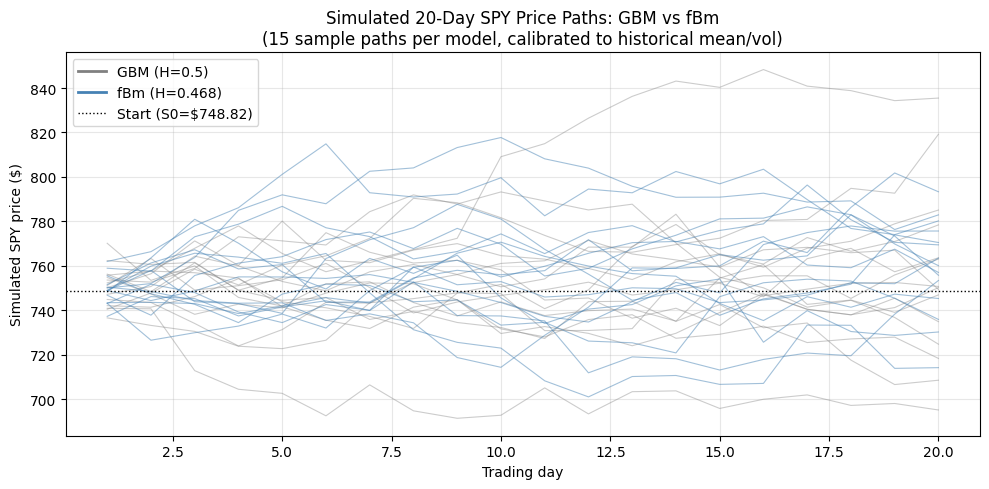

In [109]:
# --- Figure 2: Actual 20-day simulated price paths used in CVaR analysis ---
S0 = data['close'].iloc[-1]  # last actual SPY price, as the starting point

fig, ax = plt.subplots(figsize=(10, 5))

n_sample_paths = 15  # small number of individual paths, for visual clarity (not all 50,000)

# GBM sample paths
for i in range(n_sample_paths):
    price_path = S0 * np.exp(gbm_paths[i, :])
    ax.plot(range(1, N_DAYS+1), price_path, color='gray', alpha=0.4, linewidth=0.8)

# fBm (structure functions, your primary H) sample paths
for i in range(n_sample_paths):
    price_path = S0 * np.exp(fbm_paths['structure_functions'][i, :])
    ax.plot(range(1, N_DAYS+1), price_path, color='steelblue', alpha=0.5, linewidth=0.8)

# Dummy lines for a clean legend (since we plotted many individual lines above)
ax.plot([], [], color='gray', label='GBM (H=0.5)', linewidth=2)
ax.plot([], [], color='steelblue', label=f'fBm (H=0.468)', linewidth=2)
ax.axhline(S0, color='black', linestyle=':', linewidth=1, label=f'Start (S0=${S0:.2f})')

ax.set_title(f'Simulated 20-Day SPY Price Paths: GBM vs fBm\n({n_sample_paths} sample paths per model, calibrated to historical mean/vol)')
ax.set_xlabel('Trading day')
ax.set_ylabel('Simulated SPY price ($)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('module3_fbm_vs_gbm_paths.png', dpi=150)
plt.show()

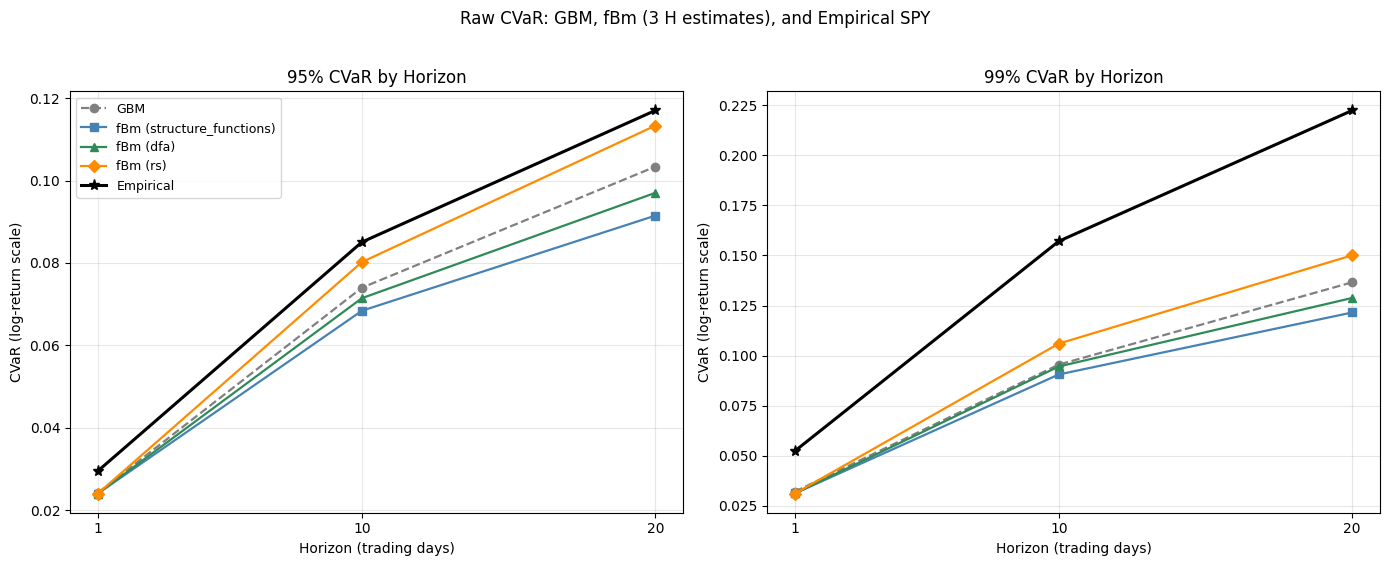

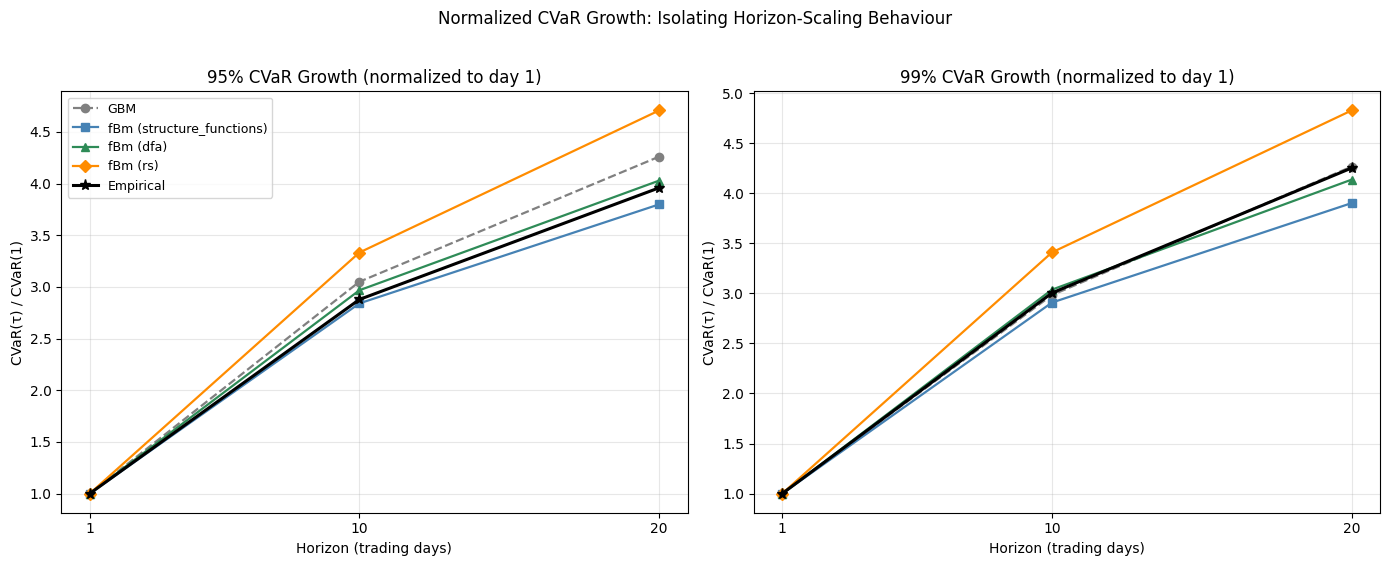

In [110]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

model_colors = {
    'GBM': 'gray',
    'fBm (structure_functions)': 'steelblue',
    'fBm (dfa)': 'seagreen',
    'fBm (rs)': 'darkorange',
    'Empirical': 'black'
}
model_styles = {
    'GBM': '--', 'fBm (structure_functions)': '-', 'fBm (dfa)': '-',
    'fBm (rs)': '-', 'Empirical': '-'
}
model_markers = {
    'GBM': 'o', 'fBm (structure_functions)': 's', 'fBm (dfa)': '^',
    'fBm (rs)': 'D', 'Empirical': '*'
}

for ax, conf in zip(axes, CONFIDENCE_LEVELS):
    subset = cvar_table[cvar_table['confidence'] == conf]
    for model in model_colors:
        ax.plot(subset['horizon'], subset[model],
                color=model_colors[model], linestyle=model_styles[model],
                marker=model_markers[model], markersize=8 if model=='Empirical' else 6,
                linewidth=2.2 if model == 'Empirical' else 1.6,
                label=model)
    ax.set_title(f'{int(conf*100)}% CVaR by Horizon')
    ax.set_xlabel('Horizon (trading days)')
    ax.set_ylabel('CVaR (log-return scale)')
    ax.set_xticks(HORIZONS)
    ax.grid(alpha=0.3)

axes[0].legend(loc='upper left', fontsize=9)
plt.suptitle('Raw CVaR: GBM, fBm (3 H estimates), and Empirical SPY', y=1.02)
plt.tight_layout()
plt.savefig('module3_cvar_raw.png', dpi=150)
plt.show()


# --- Normalized growth version ---
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, conf in zip(axes2, CONFIDENCE_LEVELS):
    subset = normalized[normalized['confidence'] == conf]
    for model in model_colors:
        ax.plot(subset['horizon'], subset[model],
                color=model_colors[model], linestyle=model_styles[model],
                marker=model_markers[model], markersize=8 if model=='Empirical' else 6,
                linewidth=2.2 if model == 'Empirical' else 1.6,
                label=model)
    ax.set_title(f'{int(conf*100)}% CVaR Growth (normalized to day 1)')
    ax.set_xlabel('Horizon (trading days)')
    ax.set_ylabel('CVaR(τ) / CVaR(1)')
    ax.set_xticks(HORIZONS)
    ax.grid(alpha=0.3)

axes2[0].legend(loc='upper left', fontsize=9)
plt.suptitle('Normalized CVaR Growth: Isolating Horizon-Scaling Behaviour', y=1.02)
plt.tight_layout()
plt.savefig('module3_cvar_normalized.png', dpi=150)
plt.show()